In [1]:
#Importing the Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Data Collection and Processing

# loading the csv data to a Pandas DataFrame
diabetes_data=pd.read_csv('/content/diabetes.csv')

In [3]:
# print first 5 rows of the dataset
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#print last 5 rows of the dataset
diabetes_data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
# getting some info about the data
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# checking for missing values
diabetes_data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
# statistical measures about the data
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# checking the distribution of Target Variable
diabetes_data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 --> Healthy Person 1 --> Diabetic Person

Splitting the Features and Target

In [9]:
X=diabetes_data.drop(columns='Outcome',axis=1)
Y=diabetes_data['Outcome']

In [10]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [11]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Splitting the Data into Training Data & Test Data

In [12]:
label_encoder = LabelEncoder()
for col in X.select_dtypes(include=['object']): # Iterate over categorical columns
    X[col] = label_encoder.fit_transform(X[col]) # Encode categorical values

In [13]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=5)

In [14]:
print(X.shape,X_train.shape,X_test.shape)

(768, 8) (614, 8) (154, 8)


Model Training

Logistic Regression

In [15]:
model=LogisticRegression()

# training the LogisticRegression model with Training data
model.fit(X_train,Y_train)

# accuracy on training data
X_train_prediction=model.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print('Accuracy on Training data:',training_data_accuracy)

# accuracy on test data
X_test_prediction=model.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)
print('Accuracy on Test data:',test_data_accuracy)

Accuracy on Training data: 0.7817589576547231
Accuracy on Test data: 0.7532467532467533


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Building a Predictive System

In [16]:
input_data = (6, 148, 72, 35, 0, 33.6, 0.627, 50)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have Diabetes')
else:
  print('The Person have Diabetes')

[1]
The Person have Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [17]:
Y_pred = model.predict(X_test)

In [18]:
conf_matrix = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_report(Y_test, Y_pred))

Confusion Matrix:
 [[88 12]
 [26 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       100
           1       0.70      0.52      0.60        54

    accuracy                           0.75       154
   macro avg       0.74      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



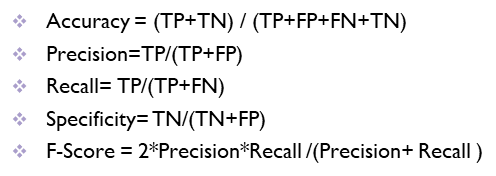

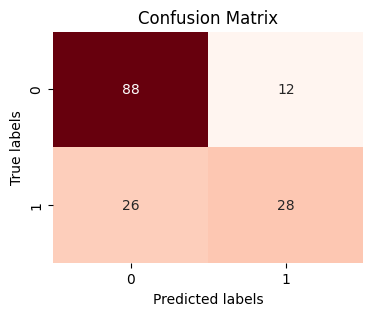

In [19]:
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, cmap="Reds", fmt="d", cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

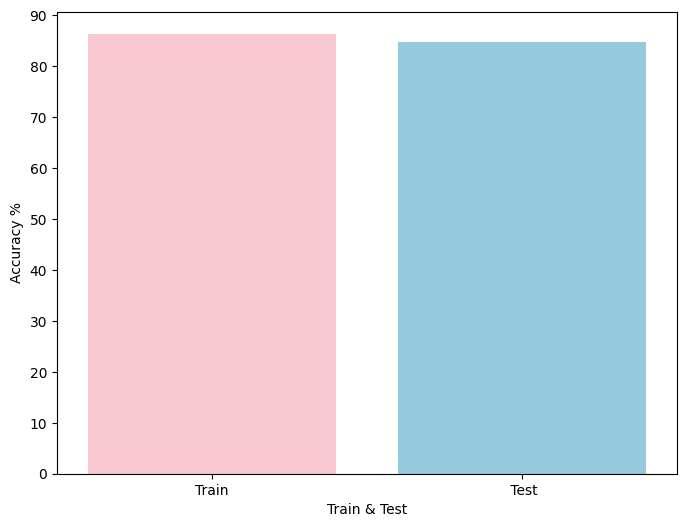

In [20]:
methods = ["Train", " Test"]
accuracy = [86.37, 84.78]
colors = ["pink", "skyblue"]

plt.figure(figsize=(8, 6))
plt.yticks(np.arange(0, 100, 10))
plt.ylabel("Accuracy %")
plt.xlabel("Train & Test")

sns.barplot(x=methods, y=accuracy, palette=colors, hue=methods, dodge=False, legend=False)
plt.show()

SVM Algorithm

In [21]:
model=SVC(kernel='linear')
# training the LogisticRegression model with Training data
model.fit(X_train,Y_train)
# accuracy on training data
X_train_prediction=model.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print('Accuracy on Training data:',training_data_accuracy)

# accuracy on test data
svm_prediction=model.predict(X_test)
test_data_accuracy=accuracy_score(svm_prediction,Y_test)
print('SVM Accuracy on Test data:',test_data_accuracy)

Accuracy on Training data: 0.7915309446254072
SVM Accuracy on Test data: 0.7532467532467533


In [22]:
input_data = (6, 148, 72, 35, 0, 33.6, 0.627, 50)
# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have Diabetes')
else:
  print('The Person have Diabetes')

[1]
The Person have Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [23]:
Y_pred = model.predict(X_test)

In [24]:
conf_matrix = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_report(Y_test, Y_pred))

Confusion Matrix:
 [[88 12]
 [26 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       100
           1       0.70      0.52      0.60        54

    accuracy                           0.75       154
   macro avg       0.74      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



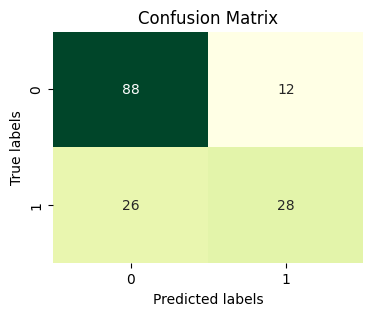

In [25]:
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, cmap="YlGn", fmt="d", cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

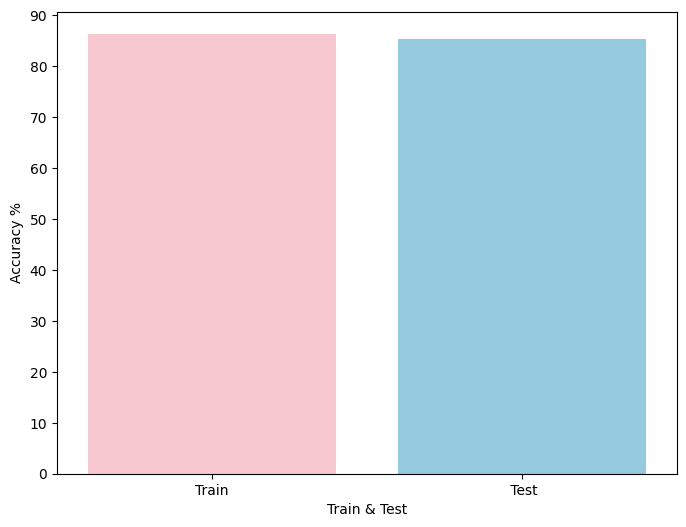

In [26]:
methods = ["Train", " Test"]
accuracy = [86.37, 85.32]
colors = ["pink", "skyblue"]

plt.figure(figsize=(8, 6))
plt.yticks(np.arange(0, 100, 10))
plt.ylabel("Accuracy %")
plt.xlabel("Train & Test")

sns.barplot(x=methods, y=accuracy, palette=colors, hue=methods, dodge=False, legend=False)
plt.show()

In [27]:
model=RandomForestClassifier(n_estimators=10)
# training the LogisticRegression model with Training data
model.fit(X_train,Y_train)
# accuracy on training data
X_train_prediction=model.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print('Accuracy on Training data:',training_data_accuracy)

# accuracy on test data
randomforest_prediction=model.predict(X_test)
randomforest_accuracy=accuracy_score(randomforest_prediction,Y_test)
print('Random Forest Accuracy on Test data:',randomforest_accuracy)

Accuracy on Training data: 0.9853420195439739
Random Forest Accuracy on Test data: 0.7337662337662337


In [28]:
input_data = (6, 148, 72, 35, 0, 33.6, 0.627, 50)
# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have Diabetes')
else:
  print('The Person have Diabetes')

[1]
The Person have Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [29]:
Y_pred = model.predict(X_test)

In [30]:
conf_matrix = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_report(Y_test, Y_pred))

Confusion Matrix:
 [[84 16]
 [25 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



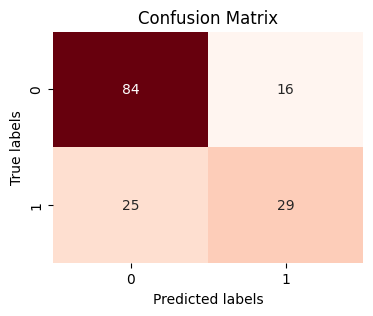

In [31]:
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, cmap="Reds", fmt="d", cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

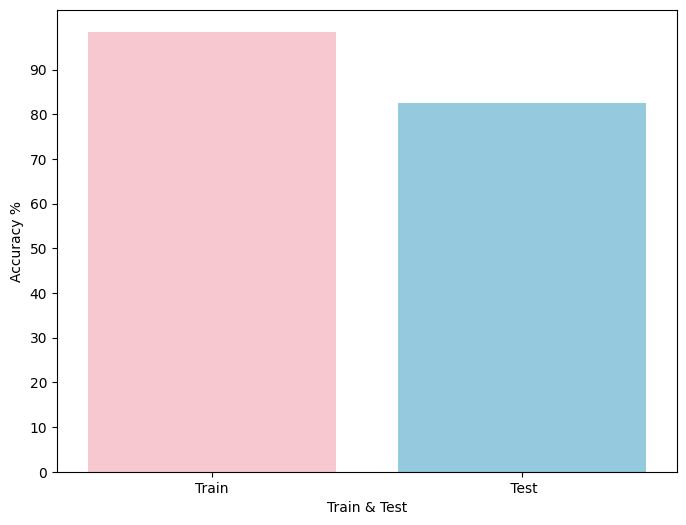

In [32]:
methods = ["Train", " Test"]
accuracy = [98.50, 82.60]
colors = ["pink", "skyblue"]

plt.figure(figsize=(8, 6))
plt.yticks(np.arange(0, 100, 10))
plt.ylabel("Accuracy %")
plt.xlabel("Train & Test")

sns.barplot(x=methods, y=accuracy, palette=colors, hue=methods, dodge=False, legend=False)
plt.show()

Building a Predictive System

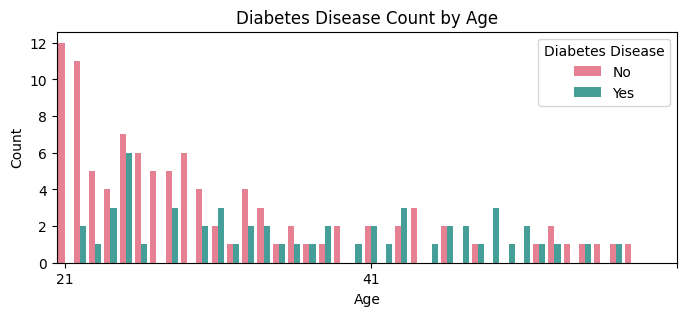

In [33]:
Y_pred = model.predict(X_test)
X_test['predicted_target'] = Y_pred
X_test['actual_target'] = Y_test
plt.figure(figsize=(8, 3))
sns.countplot(x='Age', hue='actual_target', data=X_test, palette='husl')
plt.title('Diabetes Disease Count by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Diabetes Disease', labels=['No', 'Yes'])
plt.xticks(ticks=[0,20,40])
plt.show()

In [34]:
# Defining age groups
def classify_age_group(age):
    if age <= 35:
        return 'Young'
    elif age <= 50:
        return 'Middle-aged'
    else:
        return 'Elderly'

# Adding age group column to the dataset
diabetes_data['age_group'] = diabetes_data['Age'].apply(classify_age_group)

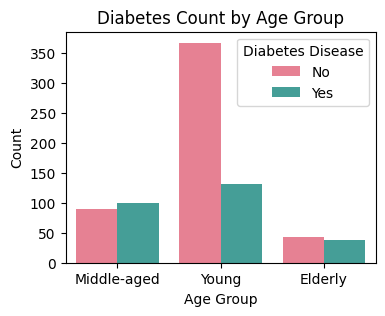

In [35]:
# Plotting bar graph classifying age groups
plt.figure(figsize=(4, 3))
sns.countplot(x='age_group', hue='Outcome', data=diabetes_data, palette='husl')
plt.title('Diabetes Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Diabetes Disease', labels=['No', 'Yes'])
plt.show()

Comparing the performance of the models

In [36]:
# list of models
models = [LogisticRegression(max_iter=1000), SVC(kernel='linear'), RandomForestClassifier()]

In [37]:
def compare_models_train_test():

  for model in models:

    # training the model
    model.fit(X_train, Y_train)

    # Get the common features between training and testing data
    common_features = X_train.columns.intersection(X_test.columns)

    # Select only the common features from the test data
    X_test_subset = X_test[common_features]

    # evaluating the model using the subset of test data
    test_data_prediction = model.predict(X_test_subset)

    accuracy = accuracy_score(Y_test, test_data_prediction)

    print('Accuracy score of the ', model, ' = ', accuracy)

In [38]:
compare_models_train_test()

Accuracy score of the  LogisticRegression(max_iter=1000)  =  0.7662337662337663
Accuracy score of the  SVC(kernel='linear')  =  0.7532467532467533
Accuracy score of the  RandomForestClassifier()  =  0.7532467532467533


Creating a Function to compare the models

In [39]:
# list of models
models = [LogisticRegression(max_iter=1000), SVC(kernel='linear'), RandomForestClassifier()]

In [40]:
def compare_models_cross_validation():

  for model in models:

    cv_score = cross_val_score(model, X,Y, cv=10)

    mean_accuracy = sum(cv_score)/len(cv_score)

    mean_accuracy = mean_accuracy*100

    mean_accuracy = round(mean_accuracy, 2)

    print('Cross Validation accuracies for ', model, '=  ', cv_score)
    print('Accuracy % of the ', model, mean_accuracy)
    print('----------------------------------------------')

In [41]:
compare_models_cross_validation()

Cross Validation accuracies for  LogisticRegression(max_iter=1000) =   [0.72727273 0.77922078 0.80519481 0.71428571 0.75324675 0.76623377
 0.80519481 0.80519481 0.75       0.82894737]
Accuracy % of the  LogisticRegression(max_iter=1000) 77.35
----------------------------------------------
Cross Validation accuracies for  SVC(kernel='linear') =   [0.7012987  0.76623377 0.79220779 0.74025974 0.74025974 0.76623377
 0.80519481 0.79220779 0.75       0.81578947]
Accuracy % of the  SVC(kernel='linear') 76.7
----------------------------------------------
Cross Validation accuracies for  RandomForestClassifier() =   [0.7012987  0.79220779 0.77922078 0.7012987  0.71428571 0.83116883
 0.80519481 0.83116883 0.71052632 0.82894737]
Accuracy % of the  RandomForestClassifier() 76.95
----------------------------------------------


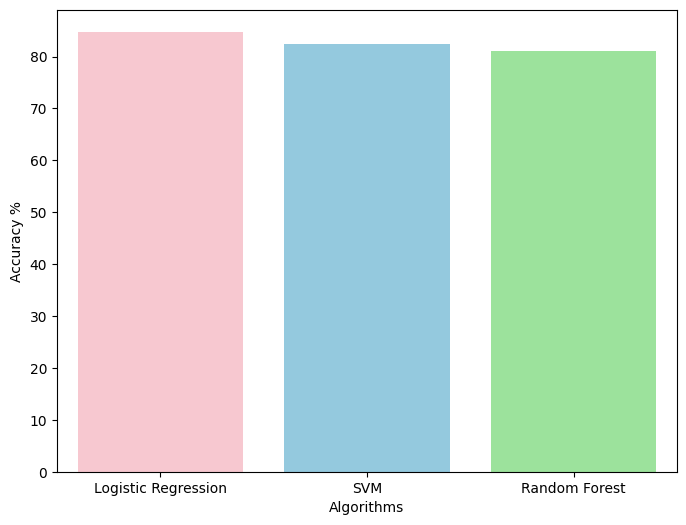

In [42]:
methods = [  "Logistic Regression", "SVM","Random Forest"]
accuracy = [  84.78, 82.32,80.97]
colors = ["Pink", "skyblue",  "lightgreen"]

plt.figure(figsize=(8, 6))
plt.yticks(np.arange(0, 100, 10))
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")

sns.barplot(x=methods, y=accuracy, palette=colors, hue=methods, dodge=False, legend=False)
plt.show()

In [43]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.1 MB/s eta 0:00:00


In [44]:
!pip install -q streamlit pyngrok pandas scikit-learn joblib

In [45]:
!pip install streamlit pyngrok

In [46]:
pip install streamlit scikit-learn pandas numpy matplotlib seaborn fpdf


  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=8cf639db477db9cd38643674c3bfe5141b402a776e6a0db872821bf22acdc9c1
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


In [47]:
!pip install streamlit pyngrok


In [48]:
from pyngrok import ngrok

# Replace with your token
!ngrok config add-authtoken 35GwFNnolLzaljcajy4yaCsue3v_Hx5AezoqjEd2i4nvDvdM

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [49]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from fpdf import FPDF
import seaborn as sns
# ------------------------------
# Set page background color (soft absorbent blue + pink gradient)
# ------------------------------
st.markdown(
    """
    <style>
    /* Entire page background with light blue to light pink gradient */
    .stApp {
        background: linear-gradient(to bottom right, #d7e8f7, #f5dfe1);
        color: #000;  /* default text color */
    }

    /* Make main content container slightly transparent for readability */
    .css-18e3th9 {
        background-color: rgba(255, 255, 255, 0.75);
        border-radius: 10px;
        padding: 10px;
    }

    /* Optional: style buttons with soft pastel colors */
    div.stButton > button {
        background: linear-gradient(to right, #a3d8f4, #fbb1c1);
        color: #000;
        border: none;
        border-radius: 5px;
        padding: 5px 10px;
    }
    div.stButton > button:hover {
        background: linear-gradient(to right, #8ccff4, #f99ab8);
    }
    </style>
    """,
    unsafe_allow_html=True

)
# ------------------------------
# Load Dataset
# ------------------------------
@st.cache_data
def load_data():
    data = pd.read_csv("diabetes.csv")
    X = data.drop(columns="Outcome", axis=1)
    Y = data["Outcome"]
    return train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=5)

X_train, X_test, Y_train, Y_test = load_data()

# Train Models
log_reg = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel="linear", probability=True)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train, Y_train)
svm_model.fit(X_train, Y_train)
rf_model.fit(X_train, Y_train)

models = {
    "Logistic Regression": log_reg,
    "SVM Algorithm": svm_model,
    "Random Forest": rf_model
}

# ------------------------------
# PAGE NAVIGATION LOGIC
# ------------------------------
if "page" not in st.session_state:
    st.session_state.page = "input"  # default page

# ------------------------------
# PAGE 1: INPUT PAGE
# ------------------------------
if st.session_state.page == "input":
    st.title("🚑 Diabetes Prediction Model 🩺")

    algo_choice = st.selectbox("**Choose Algorithm**", list(models.keys()))
    # Sample input type
    sample_choice = st.selectbox(
        "**Input Options**",
        ["Custom", "Healthy Person", "Diabetic Person"]
    )

    # Default values for samples
    if sample_choice == "Healthy Person":
        input_data = [1, 85, 66, 29, 0, 26.6, 0.351, 31]
    elif sample_choice == "Diabetic Person":
        input_data = [6, 148, 72, 35, 0, 33.6, 0.627, 50]
    else:
        # Custom sliders
        pregnancies = st.slider("Pregnancies", 0, 15, 1)
        glucose = st.slider("Glucose Level", 0, 200, 120)
        bp = st.slider("Blood Pressure", 0, 150, 70)
        skin = st.slider("Skin Thickness", 0, 100, 20)
        insulin = st.slider("Insulin Level", 0, 300, 85)
        bmi = st.slider("BMI", 10.0, 50.0, 25.0, step=0.1)
        dpf = st.slider("Diabetes Pedigree Function", 0.0, 2.5, 0.5, step=0.01)
        age = st.slider("Age", 0, 100, 30)
        input_data = [pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]

    if st.button("🔍Predict"):
        st.session_state.input_data = input_data
        st.session_state.algo_choice = algo_choice
        st.session_state.page = "result"
        st.rerun()

# ------------------------------
# PAGE 2: RESULT PAGE
# ------------------------------
elif st.session_state.page == "result":
    st.title("🧾 Prediction Result")

    input_array = np.asarray(st.session_state.input_data).reshape(1, -1)
    model = models[st.session_state.algo_choice]

    prediction = model.predict(input_array)[0]
    confidence = np.max(model.predict_proba(input_array)) * 100
    result_text = "Diabetic" if prediction == 1 else "Non-Diabetic"

    st.subheader(f"Result: {result_text}")
    st.write(f"Prediction Confidence: {confidence:.2f}%")

    features = ["Pregnency","Glucose","BP","Skin thckness","Insulin","BMI","DPF","Age"]
    fig, ax = plt.subplots(figsize=(5, 2))
    ax.bar(features, st.session_state.input_data,color=['#FF6F61','#6B5B95','#88B04B','#F7CAC9','#92A8D1'])
    ax.set_ylabel("Values", fontsize=6)
    ax.set_title("Input Feature Values", fontsize=7)
    ax.tick_params(axis='x', labelsize=5)
    ax.tick_params(axis='y', labelsize=5)
    st.pyplot(fig)

    # PDF + CSV
    def create_pdf():
        pdf = FPDF() # Create a new PDF object
        pdf.add_page() # Add a blank page
        pdf.set_font("Arial", size=12)
        pdf.cell(200, 10, txt="Diabetes Prediction Report", ln=True, align="C")
        pdf.ln(10)  # Add line break (spacing)
        features = ["Pregnency","Glucose","BP","Skin thickness","Insulin","BMI","DPF","Age"]
        # Add user input values to PDF
        for f, val in zip(features, st.session_state.input_data):
            pdf.cell(200, 10, txt=f"{f}: {val}", ln=True)
        pdf.cell(200, 10, txt=f"Result: {result_text}", ln=True)
        pdf.cell(200, 10, txt=f"Confidence: {confidence:.2f}%", ln=True)
        pdf.output("prescription.pdf")

    create_pdf()
    st.download_button("⬇️Download Prescription (PDF)",
                       data=open("prescription.pdf", "rb").read(),
                       file_name="prescription.pdf")

    features = ["Pregnency","Glucose","BP","Skin thickness","Insulin","BMI","DPF","Age"]
    csv_data = pd.DataFrame([st.session_state.input_data], columns=features)
    csv_data["Result"] = result_text
    st.download_button("⬇️Download Prescription (CSV)",
                       data=csv_data.to_csv(index=False),
                       file_name="prescription.csv",
                       mime="text/csv")

    col1, col2, col3 = st.columns([1, 0.5, 1])  # create 3 columns with small gap in middle
    with col1:
        if st.button("🔙 Back to Input"):
            st.session_state.page = "input"
            st.rerun()
    with col3:
        if st.button("🔜 Show Accuracy Comparison"):
            st.session_state.page = "comparison"
            st.rerun()

# ------------------------------
# PAGE 3: COMPARISON PAGE
# ------------------------------
elif st.session_state.page == "comparison":
    st.title("📊 Model Accuracy Comparison")

    methods = ["Logistic Regression", "SVM", "Random Forest"]
    accuracy = [84.78, 82.32, 80.97]
    colors = ["pink", "skyblue", "lightgreen"]

    fig2, ax2 = plt.subplots(figsize=(5, 2))
    ax2.set_ylim(50, 100)
    ax2.set_ylabel("Accuracy %", fontsize=8)
    ax2.set_xlabel("Algorithms", fontsize=8)
    ax2.tick_params(axis='x', labelsize=6)
    ax2.tick_params(axis='y', labelsize=6)

    sns.barplot(x=methods, y=accuracy, palette=colors, ax=ax2)
    for i, v in enumerate(accuracy):
        ax2.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=7, fontweight="normal")

    st.pyplot(fig2)

    if st.button("🔙 Back to Result"):
        st.session_state.page = "result"
        st.rerun()


Writing app.py


In [50]:
import streamlit as st
import numpy as np

In [51]:
from pyngrok import ngrok
import subprocess
import time
import os
import signal

# Kill previous ngrok processes more forcefully
!pkill ngrok

# Disconnect any existing ngrok tunnels
ngrok.kill()

# Wait to ensure processes terminate
time.sleep(5) # Increased sleep time

# Check if ngrok authtoken is configured
try:
    ngrok.get_ngrok_process()
except Exception as e:
    print(f"Error getting ngrok process: {e}")
    print("Please ensure your ngrok authtoken is correctly set up using `!ngrok config add-authtoken YOUR_AUTH_TOKEN`")
    # You might want to stop execution here if the token is not set up
    # exit()


# Start Streamlit app
# Check if the process is already running before starting
try:
    # This might not be a reliable way to check in all Colab environments
    # but we'll try
    subprocess.run(["pgrep", "-f", "streamlit run app.py"], check=True)
    print("Streamlit app is already running.")
except subprocess.CalledProcessError:
    print("Starting Streamlit app...")
    process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])


# Create public URL
try:
    public_url = ngrok.connect(8501)
    print("🌍 App URL:", public_url)
except Exception as e:
    print(f"Error creating ngrok tunnel: {e}")
    print("Please check your ngrok setup and ensure no other ngrok processes are running.")

Starting Streamlit app...
🌍 App URL: NgrokTunnel: "https://lorelei-unrescissory-herta.ngrok-free.dev" -> "http://localhost:8501"
